In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [2]:
sns.set_theme(style="whitegrid")

# 1 Data preparation

## 1.1 Load data

In [6]:
df = pd.read_csv("data_final.csv", sep=";")

df.head()

,waktu belajar,cukup atau tidak,kelas,is_cukup
0,80,tidak,D,0
1,175,tidak,D,0
2,105,tidak,C,0
3,100,tidak,C,0
4,210,tidak,D,0


# 1.2 Processing and data cleaning

In [ ]:
df["cukup atau tidak"] = df["cukup atau tidak"].astype(str).str.strip().str.lower()

df["is_cukup"] = df["cukup atau tidak"].apply(lambda x: 1 if x == "ya" else 0)

display(df.head())

,waktu belajar,cukup atau tidak,kelas,is_cukup
0,80,tidak,D,0
1,175,tidak,D,0
2,105,tidak,C,0
3,100,tidak,C,0
4,210,tidak,D,0


# 2 Exploratory data analysis

## 2.1 Statistik deskriptif

In [ ]:
print("Statistik waktu belajar:")
display(df["waktu belajar"].describe().round(2))

print("\nDistribusi sampel per kelas:")
display(df.groupby("kelas").size().reset_index(name="jumlah_mahasiswa"))

print("\nTabulasi:")
display(pd.crosstab(df["kelas"], df["cukup atau tidak"], margins=True))

Statistik waktu belajar:


count     85.00
mean     112.24
std       67.37
min        0.00
25%       60.00
50%      105.00
75%      155.00
max      355.00
Name: waktu belajar, dtype: float64


Distribusi sampel per kelas:


,kelas,jumlah_mahasiswa
0,C,43
1,D,42



Tabulasi:


cukup atau tidak,tidak,ya,All
kelas,,,
C,42,1,43
D,40,2,42
All,82,3,85


## 2.2 Visualisasi grafik

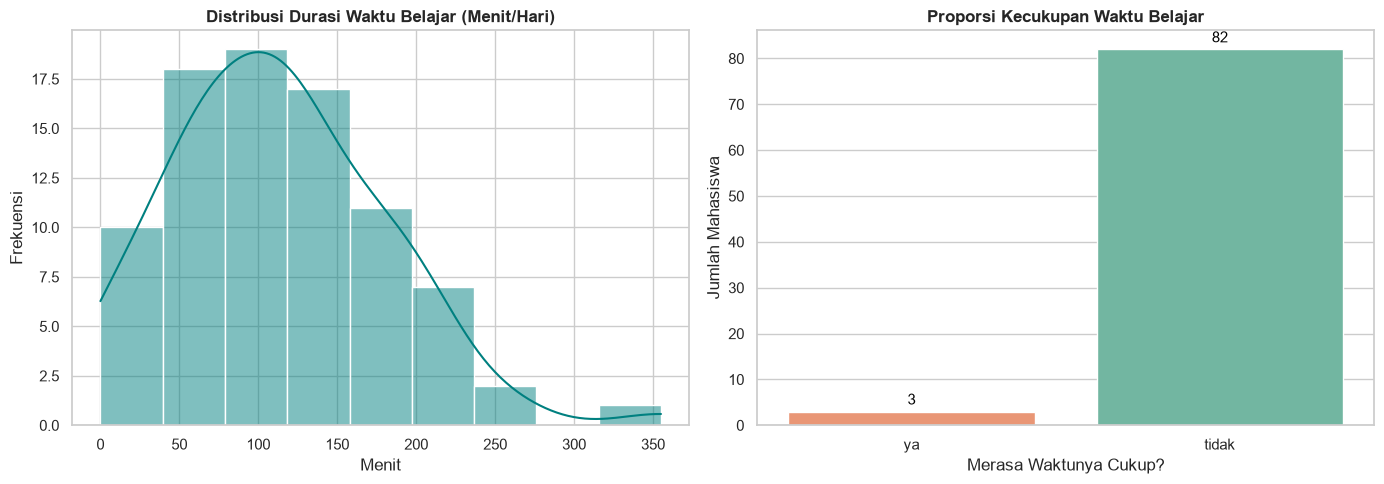

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram waktu belajar
sns.histplot(
    data=df,
    x="waktu belajar",
    kde=True,
    color="teal",
    ax=axes[0]
)
axes[0].set_title("Distribusi Durasi Waktu Belajar (Menit/Hari)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Menit")
axes[0].set_ylabel("Frekuensi")

# bar chart persepsi kecukupan waktu
sns.countplot(
    data=df,
    x="cukup atau tidak",
    hue="cukup atau tidak",
    palette="Set2",
    ax=axes[1],
    order=["ya", "tidak"]
)
axes[1].set_title("Proporsi Kecukupan Waktu Belajar", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Merasa Waktunya Cukup?")
axes[1].set_ylabel("Jumlah Mahasiswa")

# label
for p in axes[1].patches:
    axes[1].annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.,
         p.get_height()), 
        ha="center",
        va="baseline",
        fontsize=11,
        color="black",
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

# 3 Analisis

## 3.1 Estimasi cluster sampling

In [ ]:
N = 5
n = df["kelas"].nunique()
f = n / N

# agregat nilai untuk setiap klaster
cluster_stats = df.groupby("kelas").agg(
    y_i=("waktu belajar", "sum"),
    a_i=("is_cukup", "sum"),
    m_i=("kelas", "count")
).reset_index()

m_bar = cluster_stats["m_i"].mean() # rata-rata ukuran observasi per klaster

print(f"Total klaster populasi (N) : {N}")
print(f"Total klaster sampel (n)   : {n}")
print(f"Rata-rata ukuran klaster (\u0079\u0304) : {m_bar}")
display(cluster_stats)

Total klaster populasi (N) : 5
Total klaster sampel (n)   : 2
Rata-rata ukuran klaster (ȳ) : 42.5


,kelas,y_i,a_i,m_i
0,C,4985,1,43
1,D,4555,2,42


## 3.2 Estimasi parameter

In [ ]:
# estimasi rata-rata waktu belajar
y_bar_est = cluster_stats["y_i"].sum() / cluster_stats["m_i"].sum()
cluster_stats["sq_diff_mean"] = (cluster_stats["y_i"] - y_bar_est * cluster_stats["m_i"])**2
var_y_bar = ((1 - f) / (n * (m_bar**2))) * (cluster_stats["sq_diff_mean"].sum() / (n - 1))
se_y_bar = np.sqrt(var_y_bar)
moe_y_bar = 1.96 * se_y_bar

# estimasi proporsi kecukupan belajar
p_est = cluster_stats["a_i"].sum() / cluster_stats["m_i"].sum()
cluster_stats["sq_diff_prop"] = (cluster_stats["a_i"] - p_est * cluster_stats["m_i"])**2
var_p = ((1 - f) / (n * (m_bar**2))) * (cluster_stats["sq_diff_prop"].sum() / (n - 1))
se_p = np.sqrt(var_p)
moe_p = 1.96 * se_p

# output
print("Hasil Estimasi Parameter:")

print("\nEstimasi rata-rata waktu belajar:")
print(f"Estimasi titik (\u0079\u0304): {y_bar_est:.2f} menit/hari")
print(f"Standard error (SE): {se_y_bar:.2f}")
print(f"Margin of error (95%): {moe_y_bar:.2f}")
print(f"Interval kepercayaan: [{y_bar_est - moe_y_bar:.2f}, {y_bar_est + moe_y_bar:.2f}] menit")

print("\nEstimasi proporsi kecukupan belajar:")
print(f"Estimasi titik (p\u0302): {p_est:.4f} ({p_est*100:.2f}%)")
print(f"Standard error (SE): {se_p:.4f}")
print(f"Margin of error (95%): {moe_p:.4f} ({moe_p*100:.2f}%)")
print(f"Interval kepercayaan: [{(p_est - moe_p)*100:.2f}%, {(p_est + moe_p)*100:.2f}%]")

Hasil Estimasi Parameter:

Estimasi rata-rata waktu belajar:
Estimasi titik (ȳ): 112.24 menit/hari
Standard error (SE): 2.90
Margin of error (95%): 5.68
Interval kepercayaan: [106.56, 117.91] menit

Estimasi proporsi kecukupan belajar:
Estimasi titik (p̂): 0.0353 (3.53%)
Standard error (SE): 0.0094
Margin of error (95%): 0.0185 (1.85%)
Interval kepercayaan: [1.68%, 5.38%]


In [32]:
data_tabel = {
    "Parameter Statistik": [
        "Estimasi Titik", 
        "Standard Error (SE)", 
        "Margin of Error (95%)", 
        "Interval Kepercayaan"
    ],
    "Rata-rata Waktu Belajar (y\u0304)": [
        f"{y_bar_est:.2f} menit",
        f"{se_y_bar:.2f}",
        f"{moe_y_bar:.2f}",
        f"[{y_bar_est - moe_y_bar:.2f}, {y_bar_est + moe_y_bar:.2f}]"
    ],
    "Proporsi Kecukupan (p\u0302)": [
        f"{p_est:.4f} ({p_est*100:.2f}%)",
        f"{se_p:.4f}",
        f"{moe_p:.4f} ({moe_p*100:.2f}%)",
        f"[{(p_est - moe_p)*100:.2f}%, {(p_est + moe_p)*100:.2f}%]"
    ]
}

df_hasil = pd.DataFrame(data_tabel)
df_hasil.set_index("Parameter Statistik", inplace=True)

display(df_hasil)

,Rata-rata Waktu Belajar (ȳ),Proporsi Kecukupan (p̂)
Parameter Statistik,,
Estimasi Titik,112.24 menit,0.0353 (3.53%)
Standard Error (SE),2.90,0.0094
Margin of Error (95%),5.68,0.0185 (1.85%)
Interval Kepercayaan,"[106.56, 117.91]","[1.68%, 5.38%]"


In [ ]:
# simpan tabel

df_hasil.to_csv("tabel_hasil_estimasi.csv", sep=";")